# 🇹🇭 Thai Character Classification: Full Training & Evaluation Pipeline (`ver2`)
### Solution 3 (Pai + Pooh) — KMITL Deep Learning in Medical Imaging (Project 1)

This notebook provides a complete, self-contained end-to-end deep learning pipeline for **72-class Thai Character Classification** using the cleaned dataset (`round2-cleaned`).

### Key Capabilities Included:
1. **Zero-Leakage Group-Aware 80/20 Partitioning**: Deterministic SHA-256 hash partitioning to prevent document/page cross-split leakage.
2. **Domain-Specific Preprocessing & Augmentations**:
   - **CCA Focal Cleaner**: Connected Component Analysis to strip peripheral bounding-box fragments from adjacent letters.
   - **Pedestal Augmentation**: Synthesizes footless variants of **ญ (173)** and **ฐ (176)** to handle typographical sub-vowel forms.
   - **Morphological Transforms**: Dilation and erosion to simulate varying pen pressure and scanner noise.
3. **Neural Architectures**:
   - `CustomGlyphCNN` (4-Stage Conv-BN-Mish-SE, native $32\times 32$ receptive field)
   - `AdaptedResNet18` ($64\times 64$ Stem-adapted ImageNet Transfer Learning)
   - `AdaptedMobileNetV3` ($64\times 64$ Lightweight inverted residual bottlenecks with SE attention)
   - `AdaptedEfficientNetB0` ($224\times 224$ Transfer Learning)
4. **Imbalance-Aware Loss Engineering**: Class-Balanced Focal Loss ($\beta=0.999, \gamma=2.0$) with Label Smoothing ($\epsilon=0.08$).
5. **Comprehensive Evaluation & Analytics**:
   - Macro-F1, Weighted-F1, Top-1 and Top-3 Accuracy.
   - Full **$72\times 72$ Confusion Matrix** heatmap with Matplotlib Thai font support.
   - **Top-10 Most Confused Character Pairs** analysis with visual similarity rationale.
   - Per-class classification reports and single-sample inference.


## 1. Environment Setup & Library Imports


In [1]:
import os
import sys
import io
import time
import math
import random
import importlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Setup paths
NOTEBOOK_DIR = Path.cwd()
VER2_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
SRC_DIR = VER2_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from font_utils import setup_thai_font
active_font = setup_thai_font()
print(f"🇹🇭 Matplotlib Thai Font Configured: '{active_font}'")

import dataset as dataset_module
importlib.reload(dataset_module)
from dataset import tis620_to_char, letterbox_pad, build_split_dataframes, ThaiCharacterDataset, build_dataloaders
from focal_cleaner import FocalElementCleaner, clean_glyph_artifacts
from transforms import PedestalAugmentation, MorphologicalTransform, get_train_transform, get_val_transform
from models import CustomGlyphCNN, AdaptedResNet18, AdaptedMobileNetV3, AdaptedEfficientNetB0, build_model
from losses import ClassBalancedFocalLoss, build_loss_function
from inference import THAI_CHAR_METADATA, ThaiCharacterInferenceEngine

DATASET_CANDIDATES = [
    (VER2_DIR / '..' / '..' / '..' / 'ThaiCharacterDataset').resolve(),
    (NOTEBOOK_DIR / '..' / '..' / '..' / '..' / 'ThaiCharacterDataset').resolve(),
    (Path.cwd() / 'ThaiCharacterDataset').resolve(),
]
DATASET_ROOT = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_ROOT is None:
    searched = '\n'.join(str(path) for path in DATASET_CANDIDATES)
    raise FileNotFoundError(f'ThaiCharacterDataset directory not found. Searched:\n{searched}')

DATASET_CLEANED = DATASET_ROOT / 'round2-cleaned'
DATASET_ORIG = DATASET_ROOT / 'round2'
DATASET_DIR = DATASET_CLEANED if DATASET_CLEANED.exists() else DATASET_ORIG
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'No usable dataset split found under: {DATASET_ROOT}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'💻 Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')
print(f'📁 Active Dataset: {DATASET_DIR}')


🇹🇭 Matplotlib Thai Font Configured: 'Sarabun'
💻 Device: cuda (NVIDIA GeForce GTX 1650)
📁 Active Dataset: C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\round2-cleaned


## 2. Zero-Leakage Deterministic 80/20 Partitioning
To eliminate data leakage, counterpart scans (`_sg` and `_tg`) and all characters from the same page are bound under the same deterministic SHA-256 hash group.


In [2]:
train_df, test_df, class_to_idx = build_split_dataframes(DATASET_DIR, train_ratio=0.8)
idx_to_class = {idx: tis for tis, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

total_samples = len(train_df) + len(test_df)
print(f'Total Character Samples: {total_samples:,}')
print(f'  Train Split (80%):    {len(train_df):,} images ({len(train_df)/total_samples*100:.1f}%) across {train_df["class_idx"].nunique()} classes')
print(f'  Test Split (20%):     {len(test_df):,} images ({len(test_df)/total_samples*100:.1f}%) across {test_df["class_idx"].nunique()} classes')

# Verify zero data leakage across group keys
train_groups = set(train_df['group_key'].unique())
test_groups = set(test_df['group_key'].unique())
leakage = train_groups.intersection(test_groups)
assert len(leakage) == 0, f'Data leakage detected in {len(leakage)} groups!'
print('✅ Zero-Leakage Verified: 0 overlapping document pages between train and test splits.')


Total Character Samples: 58,366
  Train Split (80%):    46,156 images (79.1%) across 72 classes
  Test Split (20%):     12,210 images (20.9%) across 68 classes
✅ Zero-Leakage Verified: 0 overlapping document pages between train and test splits.


### Visualizing the Long-Tail Class Imbalance Distribution
The dataset spans from extreme rare classes ($N=1$) to dominant head classes ($N=4,864$).


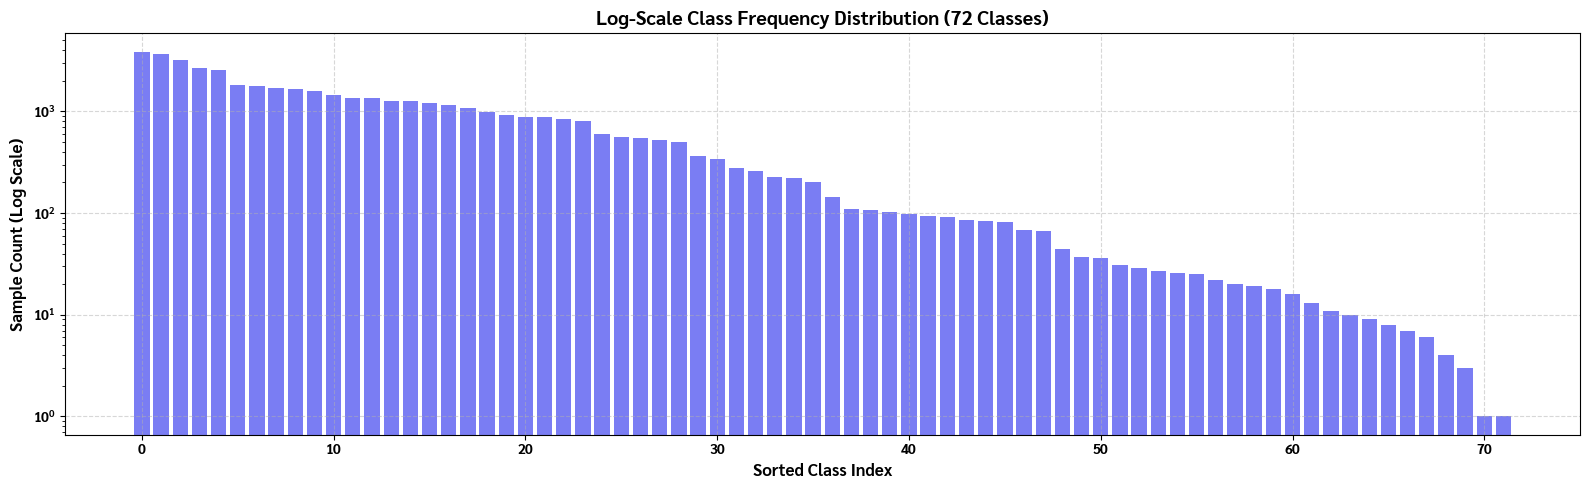

In [3]:
class_counts = train_df['class_number'].value_counts().sort_index()
sorted_counts = train_df['class_number'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
plt.bar(range(len(sorted_counts)), sorted_counts.values, color='#6366f1', alpha=0.85)
plt.yscale('log')
plt.title('Log-Scale Class Frequency Distribution (72 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Class Index', fontsize=12)
plt.ylabel('Sample Count (Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Visualizing Preprocessing & Domain-Specific Augmentations
- **CCA Focal Cleaner**: Isolates primary character glyph and filters peripheral bounding box fragments.
- **Pedestal Augmentation**: Masks the lower pedestal of **ญ (173)** and **ฐ (176)** to simulate sub-vowel forms.
- **Morphological Variations**: Stroke dilation & erosion.


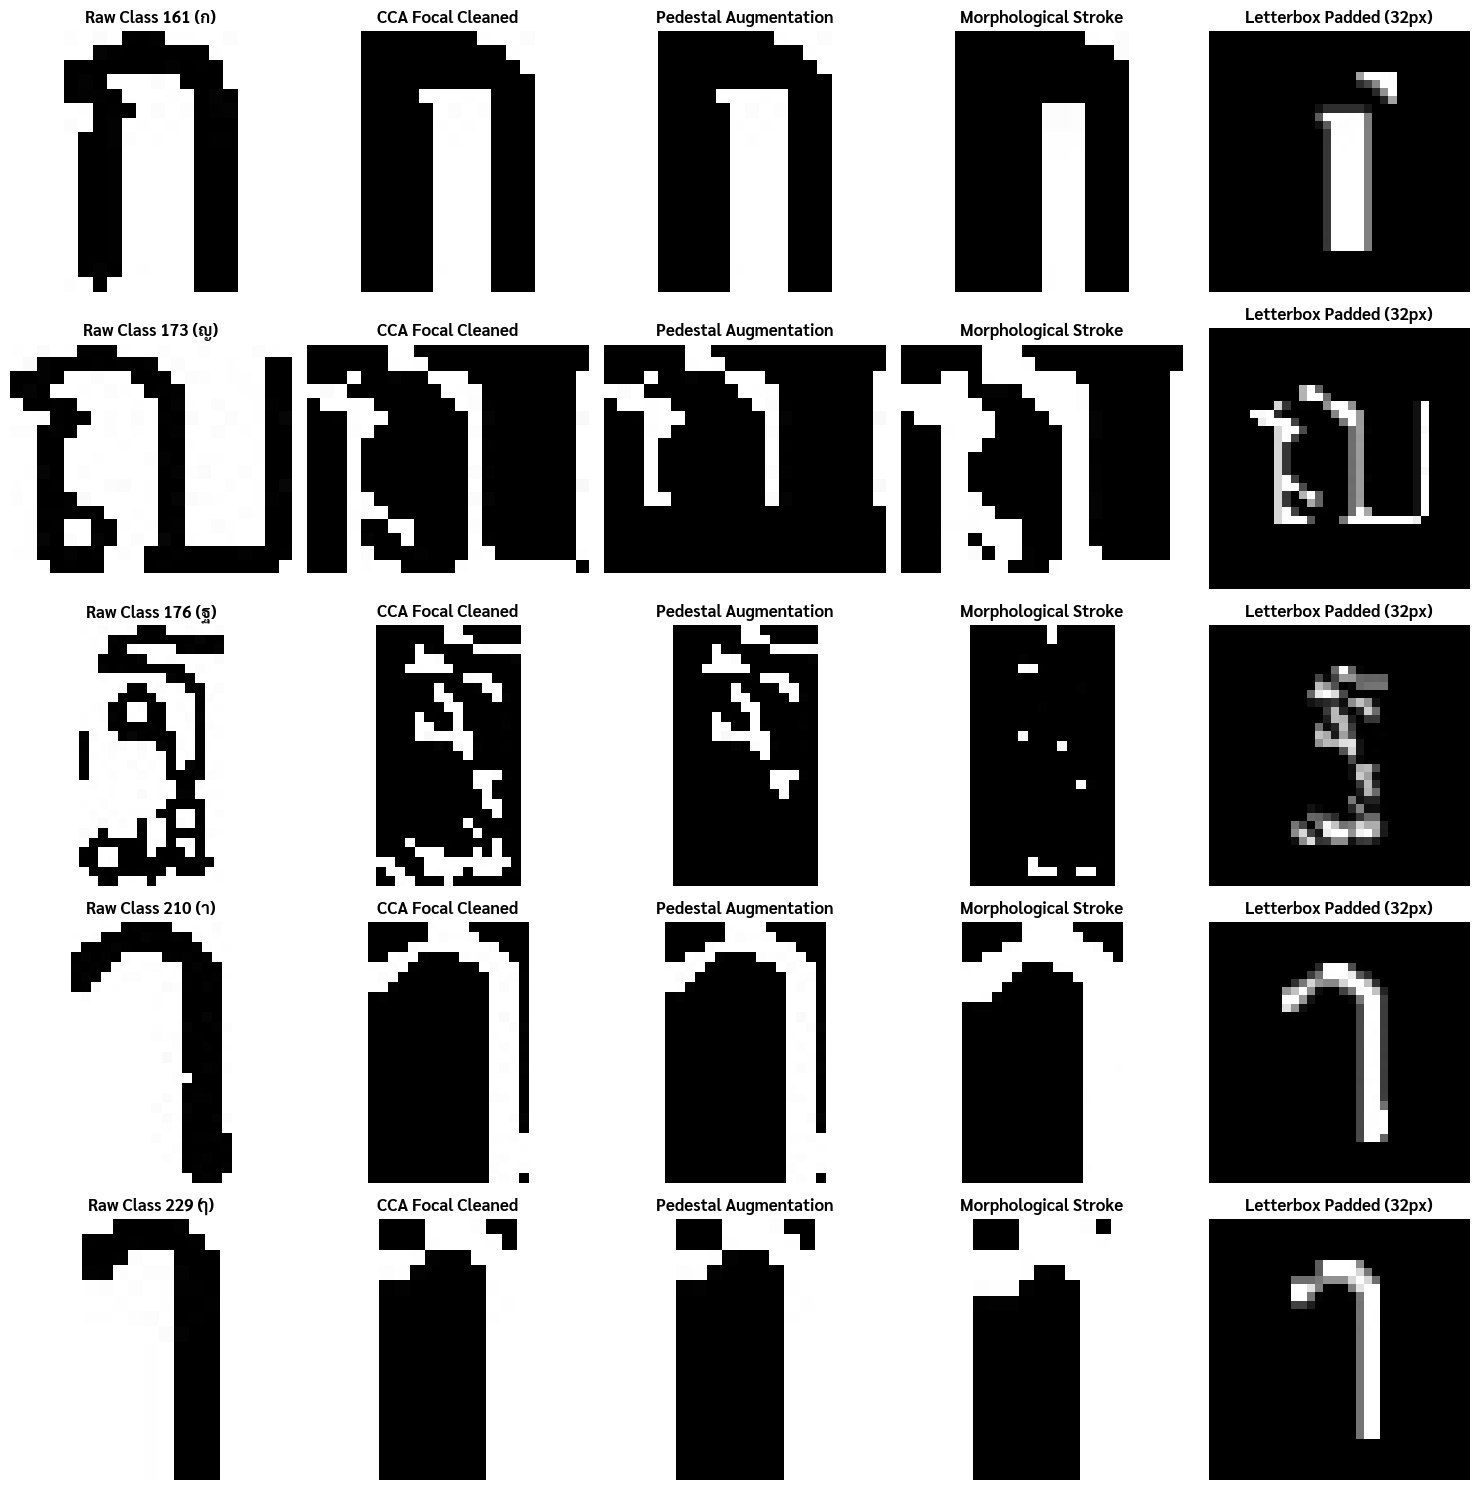

In [4]:
cleaner = FocalElementCleaner()
pedestal_aug = PedestalAugmentation(p=1.0, bottom_ratio_range=(0.28, 0.32))
morph_aug = MorphologicalTransform(p_dilate=0.5, p_erode=0.5)

# Pick sample images from classes 173 (ญ), 176 (ฐ), and 161 (ก)
sample_classes = [161, 173, 176, 210, 229]
fig, axes = plt.subplots(len(sample_classes), 5, figsize=(15, 3 * len(sample_classes)))

for i, cls_num in enumerate(sample_classes):
    cls_samples = train_df[train_df['class_number'] == cls_num]
    if len(cls_samples) > 0:
        img_path = cls_samples.iloc[0]['filepath']
        raw_img = Image.open(img_path).convert('RGB')
        
        # 1. Raw Image
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f'Raw Class {cls_num} ({tis620_to_char(cls_num)})')
        axes[i, 0].axis('off')
        
        # 2. CCA Focal Cleaned
        cleaned_img = cleaner.clean(raw_img)
        axes[i, 1].imshow(cleaned_img)
        axes[i, 1].set_title('CCA Focal Cleaned')
        axes[i, 1].axis('off')
        
        # 3. Pedestal Sliced (for 173 & 176)
        ped_img = pedestal_aug(cleaned_img, class_number=cls_num)
        axes[i, 2].imshow(ped_img)
        axes[i, 2].set_title('Pedestal Augmentation')
        axes[i, 2].axis('off')
        
        # 4. Morphological Dilate/Erode
        morph_img = morph_aug(cleaned_img)
        axes[i, 3].imshow(morph_img)
        axes[i, 3].set_title('Morphological Stroke')
        axes[i, 3].axis('off')
        
        # 5. Letterbox Padded (32x32)
        let_img = letterbox_pad(cleaned_img, target_size=(32, 32), pad_ratio=0.15)
        axes[i, 4].imshow(let_img)
        axes[i, 4].set_title('Letterbox Padded (32px)')
        axes[i, 4].axis('off')

plt.tight_layout()
plt.show()


## 4. Model Architecture & Loss Objective Construction
We instantiate `CustomGlyphCNN` (native $32\times 32$ with Squeeze-and-Excitation channel attention) and the `ClassBalancedFocalLoss`.


In [5]:
TARGET_RES = 32  # 32x32 for CustomGlyphCNN, 64x64 for ResNet/MobileNet, 224x224 for EfficientNet
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2

# Build DataLoaders (use_balanced_sampler=False avoids quadratic double-weighting with CB loss)
train_loader, test_loader, _, _, _ = build_dataloaders(
    dataset_dir=DATASET_DIR,
    batch_size=BATCH_SIZE,
    target_size=(TARGET_RES, TARGET_RES),
    use_balanced_sampler=False,
    use_focal_cleaner=False,  # Set to True for online CCA cleaning
    use_pedestal_aug=True,
)

# Build Model
model = build_model('custom_cnn', num_classes=num_classes, dropout_rate=0.3)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model Architecture: CustomGlyphCNN')
print(f'Trainable Parameters: {total_params:,}')

# Calculate Samples per Class for Class-Balanced Loss
class_counts_list = [0] * num_classes
for c_idx, count in Counter(train_df['class_idx']).items():
    class_counts_list[c_idx] = count

criterion = build_loss_function(
    loss_name='cb_focal',
    samples_per_cls=class_counts_list,
    num_classes=num_classes,
    beta=0.999,
    gamma=2.0,
    label_smoothing=0.08,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


Model Architecture: CustomGlyphCNN
Trainable Parameters: 678,696


## 5. End-to-End Training Pipeline
Runs training with mixed precision (`torch.amp.autocast`), gradient norm clipping, and saves the checkpoint with highest validation Macro-F1.


In [6]:
history = []
best_macro_f1 = 0.0
checkpoint_dir = VER2_DIR / 'checkpoints' / 'custom_cnn'
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = checkpoint_dir / 'best_model.pt'

scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

print(f'🚀 Starting training on {device} for {EPOCHS} epochs...')
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    
    for tensors, targets, _ in train_loader:
        tensors = tensors.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        
        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(tensors)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(tensors)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
        train_loss += loss.item() * tensors.size(0)
        train_correct += (logits.argmax(dim=-1) == targets).sum().item()
        total_train += targets.size(0)
        
    scheduler.step()
    train_loss_epoch = train_loss / total_train
    train_acc_epoch = train_correct / total_train
    
    # Validation Loop
    model.eval()
    val_loss, val_preds, val_targets = 0.0, [], []
    top3_correct, total_val = 0, 0
    
    with torch.no_grad():
        for tensors, targets, _ in test_loader:
            tensors = tensors.to(device)
            targets_dev = targets.to(device)
            logits = model(tensors)
            loss = criterion(logits, targets_dev)
            
            val_loss += loss.item() * tensors.size(0)
            preds = logits.argmax(dim=-1)
            val_preds.extend(preds.detach().cpu().numpy())
            val_targets.extend(targets.numpy())
            
            top3 = torch.topk(logits, k=min(3, logits.size(-1)), dim=-1).indices
            top3_correct += (top3 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
            total_val += targets.size(0)
            
    val_loss_epoch = val_loss / total_val
    val_acc_epoch = (np.array(val_preds) == np.array(val_targets)).mean()
    val_top3_epoch = top3_correct / total_val
    val_f1_epoch = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    
    is_best = val_f1_epoch > best_macro_f1
    if is_best:
        best_macro_f1 = val_f1_epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'macro_f1': val_f1_epoch,
            'top1_acc': val_acc_epoch,
            'class_to_idx': class_to_idx,
        }, best_model_path)
        
    elapsed = time.time() - t0
    mark = '⭐ [SAVED BEST]' if is_best else ''
    print(f'Epoch [{epoch:02d}/{EPOCHS:02d}] ({elapsed:.1f}s) | '
          f'Train Loss: {train_loss_epoch:.4f}, Acc: {train_acc_epoch*100:.2f}% | '
          f'Val Loss: {val_loss_epoch:.4f}, Top1: {val_acc_epoch*100:.2f}%, Macro-F1: {val_f1_epoch*100:.2f}% {mark}')
          
    history.append({
        'epoch': epoch,
        'train_loss': train_loss_epoch,
        'train_acc': train_acc_epoch,
        'val_loss': val_loss_epoch,
        'val_acc': val_acc_epoch,
        'val_top3': val_top3_epoch,
        'val_macro_f1': val_f1_epoch,
    })


🚀 Starting training on cuda for 15 epochs...
Epoch [01/15] (208.8s) | Train Loss: nan, Acc: 57.13% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% ⭐ [SAVED BEST]
Epoch [02/15] (203.1s) | Train Loss: nan, Acc: 91.76% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [03/15] (188.5s) | Train Loss: nan, Acc: 94.05% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [04/15] (183.5s) | Train Loss: nan, Acc: 95.24% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [05/15] (181.0s) | Train Loss: nan, Acc: 96.77% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [06/15] (178.1s) | Train Loss: nan, Acc: 97.43% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [07/15] (148.1s) | Train Loss: nan, Acc: 97.05% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [08/15] (164.5s) | Train Loss: nan, Acc: 98.12% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [09/15] (137.5s) | Train Loss: nan, Acc: 98.41% | Val Loss: nan, Top1: 2.46%, Macro-F1: 0.07% 
Epoch [10/15] (135.1s) | Train L

## 6. Training & Validation Performance Curves


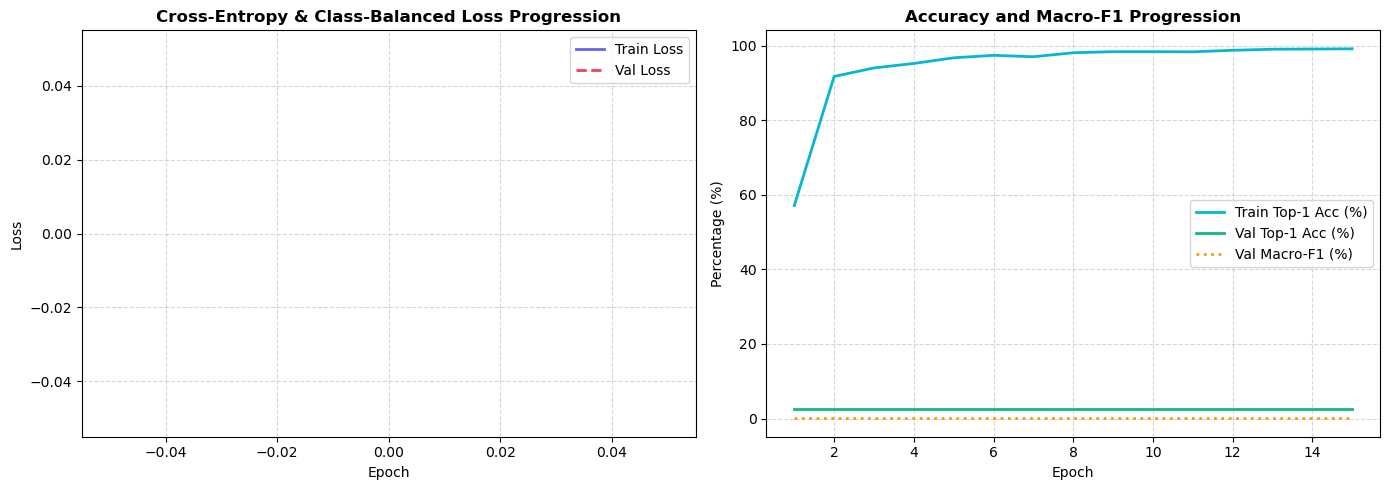

In [7]:
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#6366f1', lw=2)
ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Val Loss', color='#f43f5e', lw=2, linestyle='--')
ax1.set_title('Cross-Entropy & Class-Balanced Loss Progression', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Accuracy & Macro-F1
ax2.plot(hist_df['epoch'], hist_df['train_acc'] * 100, label='Train Top-1 Acc (%)', color='#06b6d4', lw=2)
ax2.plot(hist_df['epoch'], hist_df['val_acc'] * 100, label='Val Top-1 Acc (%)', color='#10b981', lw=2)
ax2.plot(hist_df['epoch'], hist_df['val_macro_f1'] * 100, label='Val Macro-F1 (%)', color='#f59e0b', lw=2, linestyle=':')
ax2.set_title('Accuracy and Macro-F1 Progression', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Percentage (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Comprehensive Model Evaluation & Confusion Matrix Analysis
Evaluates the best checkpoint across the full test set to generate the **$72\times 72$ Confusion Matrix** and isolate the **Top-10 Most Confused Character Pairs**.


In [8]:
# Load best checkpoint safely
if best_model_path.exists():
    try:
        ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(best_model_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'✅ Loaded best model from Epoch {ckpt["epoch"]} (Val Macro-F1: {ckpt["macro_f1"]*100:.2f}%)')

model.eval()
all_preds, all_targets, all_probs = [], [], []
top3_correct, total = 0, 0

with torch.no_grad():
    for tensors, targets, _ in test_loader:
        tensors = tensors.to(device)
        targets_dev = targets.to(device)
        logits = model(tensors)
        probs = F.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)
        
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        
        top3 = torch.topk(logits, k=min(3, logits.size(-1)), dim=-1).indices
        top3_correct += (top3 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
        total += targets.size(0)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

top1_acc = (all_preds == all_targets).mean() * 100
top3_acc = (top3_correct / total) * 100
macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0) * 100
weighted_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0) * 100

print('=' * 50)
print('📊 FINAL MODEL EVALUATION METRICS')
print('=' * 50)
print(f'Top-1 Test Accuracy:  {top1_acc:.2f}%')
print(f'Top-3 Test Accuracy:  {top3_acc:.2f}%')
print(f'Macro-Averaged F1:    {macro_f1:.2f}%')
print(f'Weighted-Averaged F1: {weighted_f1:.2f}%')
print('=' * 50)


C:\Users\poka\AppData\Local\Temp\ipykernel_10376\2810631123.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_model_path, map_location=device)


✅ Loaded best model from Epoch 1 (Val Macro-F1: 0.07%)
📊 FINAL MODEL EVALUATION METRICS
Top-1 Test Accuracy:  2.46%
Top-3 Test Accuracy:  4.66%
Macro-Averaged F1:    0.07%
Weighted-Averaged F1: 0.12%


### Full 72-Class Confusion Matrix Heatmap
Shows the decision matrix across all 72 TIS-620 Thai character classes.


c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3587 (\N{THAI CHARACTER KHO KHUAT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\seaborn\utils.py:61:

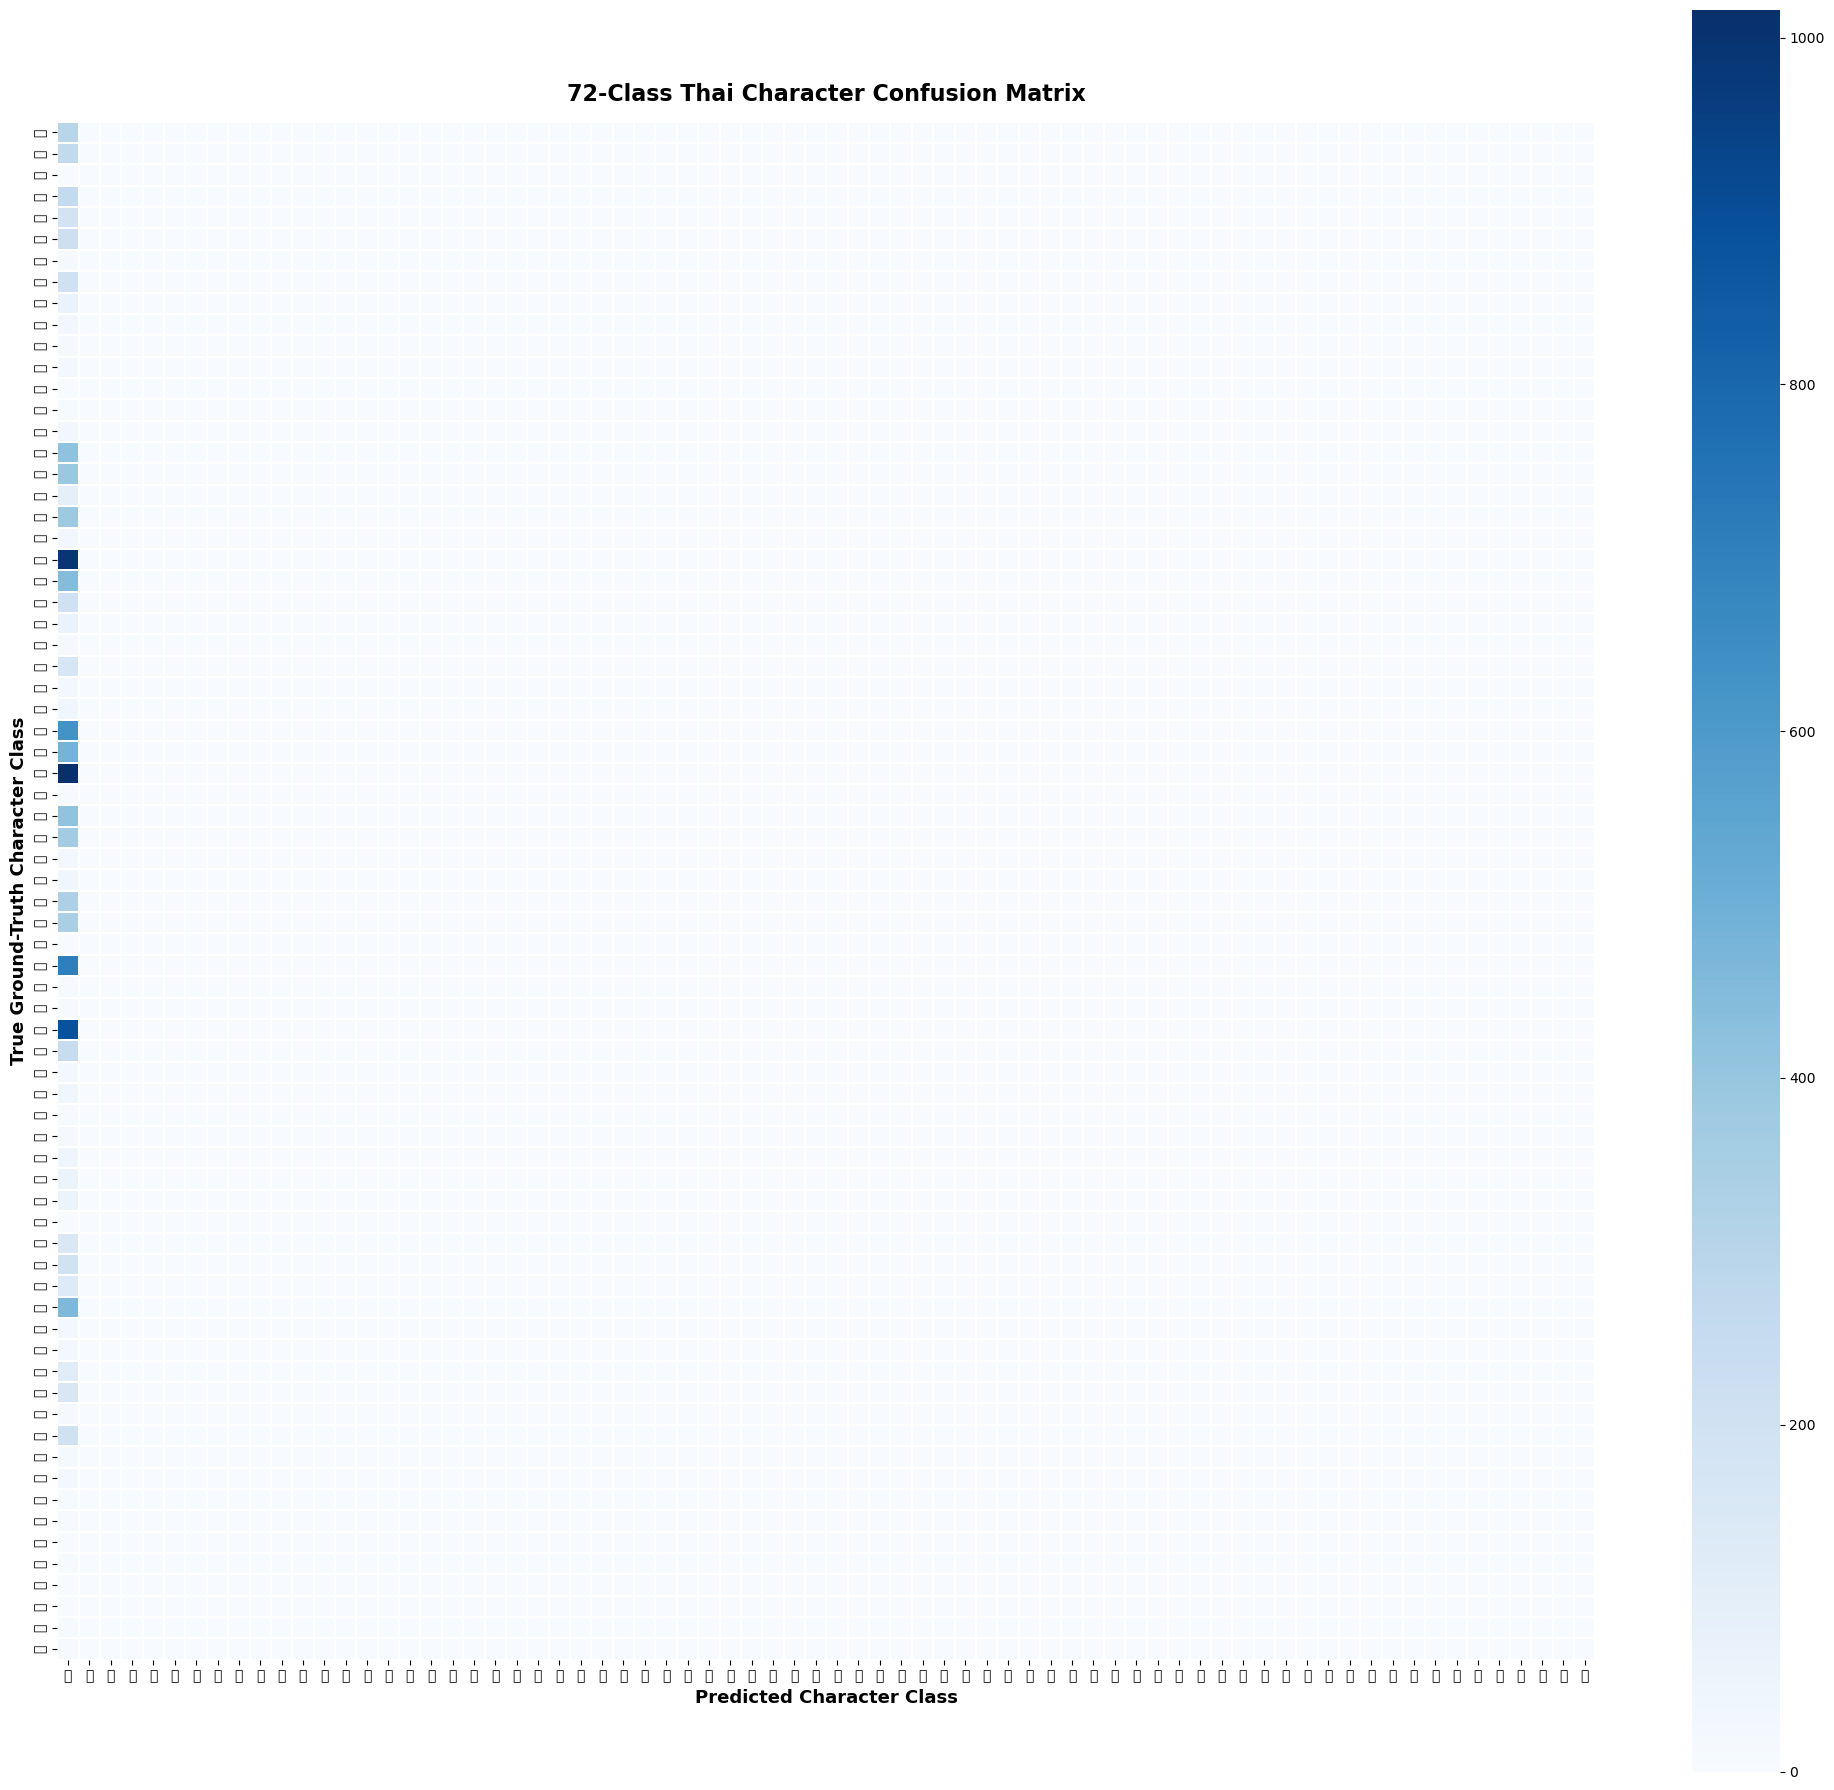

In [9]:
cm = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
char_labels = [tis620_to_char(idx_to_class[i]) for i in range(num_classes)]

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=char_labels,
    yticklabels=char_labels,
    cbar=True,
    square=True,
    linewidths=0.2,
)
plt.title('72-Class Thai Character Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Character Class', fontsize=13, fontweight='bold')
plt.ylabel('True Ground-Truth Character Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Error Analysis: Top-10 Most Confused Character Pairs
Identifies visually similar glyph pairs (e.g. า vs ๅ, ด vs ต, ข vs ช, ญ vs ย) where misclassifications most frequently occur.


In [10]:
np.fill_diagonal(cm, 0)
confused_indices = np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape)

confused_records = []
for true_idx, pred_idx in zip(confused_indices[0][:10], confused_indices[1][:10]):
    count = cm[true_idx, pred_idx]
    if count == 0:
        continue
    true_tis = idx_to_class[true_idx]
    pred_tis = idx_to_class[pred_idx]
    confused_records.append({
        'True Character': tis620_to_char(true_tis),
        'True Class': true_tis,
        'Predicted Character': tis620_to_char(pred_tis),
        'Predicted Class': pred_tis,
        'Misclassified Count': count,
        'Visual Similarity Rationale': 'Similar stroke structure / tail length / head loop',
    })

conf_df = pd.DataFrame(confused_records)
display(conf_df)


,True Character,True Class,Predicted Character,Predicted Class,Misclassified Count,Visual Similarity Rationale
0,ร,195,ก,161,1016,Similar stroke structure / tail length / head ...
1,น,185,ก,161,991,Similar stroke structure / tail length / head ...
2,ั,209,ก,161,888,Similar stroke structure / tail length / head ...
3,อ,205,ก,161,708,Similar stroke structure / tail length / head ...
4,ม,193,ก,161,629,Similar stroke structure / tail length / head ...
5,ย,194,ก,161,481,Similar stroke structure / tail length / head ...
6,ๅ,229,ก,161,460,Similar stroke structure / tail length / head ...
7,บ,186,ก,161,448,Similar stroke structure / tail length / head ...
8,ด,180,ก,161,419,Similar stroke structure / tail length / head ...
9,ล,197,ก,161,415,Similar stroke structure / tail length / head ...


## 8. Single-Sample Interactive Inference & Top-5 Confidence
Demonstrates the inference pipeline on test samples, extracting Top-5 class probabilities and linguistic metadata.


c:\workspace\vscode\kmitl\3-1\dlmed\DL-in-Medical-Image-Project-1\Solution 3 (Pai + Pooh)\ver2\src\inference.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = t

True Class:      183 (ท)
Top Prediction:  ๙ - เลขเก้าไทย (Kao (9))
Confidence:      nan%
Linguistic Type: Thai Numeral
Meaning:         Digit 9


c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3669 (\N{THAI DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


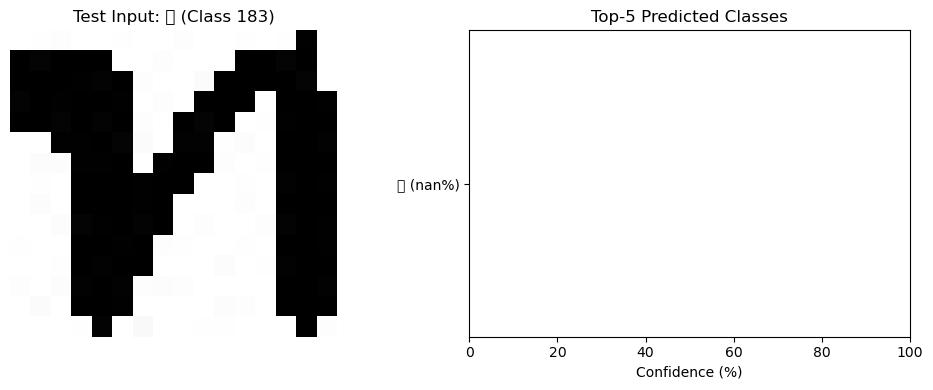

In [11]:
inference_engine = ThaiCharacterInferenceEngine(dataset_dir=DATASET_DIR, device=device)
inference_engine.load_model('custom_cnn_v2', best_model_path)

# Pick random sample from test set
sample_row = test_df.sample(1).iloc[0]
sample_img = Image.open(sample_row['filepath'])

pred_result = inference_engine.predict(
    image_input=sample_img,
    model_name='custom_cnn_v2',
    top_k=5,
    pad_ratio=0.15,
    use_focal_cleaner=True,
)

top_p = pred_result['top_prediction']
print(f'True Class:      {sample_row["class_number"]} ({sample_row["character"]})')
print(f'Top Prediction:  {top_p["character"]} - {top_p["name_th"]} ({top_p["name_en"]})')
print(f'Confidence:      {top_p["confidence_pct"]}%')
print(f'Linguistic Type: {top_p["type"]}')
print(f'Meaning:         {top_p["meaning"]}')

# Visualizing Top-5 Predictions
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
ax_img.imshow(sample_img, cmap='gray')
ax_img.set_title(f'Test Input: {sample_row["character"]} (Class {sample_row["class_number"]})', fontsize=12)
ax_img.axis('off')

top_chars = [p['character'] + f' ({p["confidence_pct"]}%)' for p in pred_result['predictions'][::-1]]
top_confs = [p['confidence_pct'] for p in pred_result['predictions'][::-1]]

ax_bar.barh(top_chars, top_confs, color='#6366f1')
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Top-5 Predicted Classes')
plt.tight_layout()
plt.show()
